# UAS Kecerdasan Buatan (SIF210)
## Sistem Penjadwalan Otomatis Mata Kuliah dengan Algoritma Genetika

**Nama    :** Hafizh Akramullah
**NIM     :** 24146054

Notebook ini berisi implementasi Algoritma Genetika (Genetic Algorithm) untuk
menyusun jadwal 24 mata kuliah ke dalam kombinasi ruang dan slot waktu,
dengan tujuan meminimalkan konflik penjadwalan (konflik ruang, konflik
dosen-waktu, dan konflik dosen-hari).


## 1. Import Library

In [ ]:
import random
import matplotlib.pyplot as plt

random.seed()  # tanpa seed tetap (full random) sesuai kesepakatan
print("Library berhasil diimpor.")


Library berhasil diimpor.


## 2. Data Mata Kuliah, Ruang, dan Slot Waktu

Data berikut sesuai dengan ketentuan soal UAS: 24 mata kuliah dengan 6 dosen
tetap, 4 ruang kelas, dan 12 slot waktu (Senin-Kamis, 3 sesi per hari).

In [ ]:
courses = [
    ("AI", "DosenA"), ("ML", "DosenB"), ("DB", "DosenC"),
    ("CN", "DosenD"), ("SE", "DosenE"), ("OS", "DosenF"),
    ("IR", "DosenA"), ("NLP", "DosenB"), ("CV", "DosenC"),
    ("IOT", "DosenD"), ("HCI", "DosenE"), ("CyberSec", "DosenF"),
    ("BigData", "DosenA"), ("DL", "DosenB"), ("NoSQL", "DosenC"),
    ("Cloud", "DosenD"), ("UX", "DosenE"), ("SecEng", "DosenF"),
    ("Agile", "DosenA"), ("RL", "DosenB"), ("ETL", "DosenC"),
    ("DevOps", "DosenD"), ("GameDev", "DosenE"), ("Blockchain", "DosenF"),
]

rooms = ["R1", "R2", "R3", "R4"]

timeslots = [
    "Senin-08", "Senin-10", "Senin-13",
    "Selasa-08", "Selasa-10", "Selasa-13",
    "Rabu-08", "Rabu-10", "Rabu-13",
    "Kamis-08", "Kamis-10", "Kamis-13",
]

N_COURSES = len(courses)
print(f"Jumlah mata kuliah : {N_COURSES}")
print(f"Jumlah ruang       : {len(rooms)}")
print(f"Jumlah slot waktu  : {len(timeslots)}")


Jumlah mata kuliah : 24
Jumlah ruang       : 4
Jumlah slot waktu  : 12


## 3. Parameter Algoritma Genetika

Sesuai instruksi soal: populasi awal 60 individu, generasi maksimum 100,
tingkat crossover 85%, dan tingkat mutasi 20%.

In [ ]:
POP_SIZE = 60
MAX_GEN = 100
CROSSOVER_RATE = 0.85
MUTATION_RATE = 0.20


## 4. Representasi Individu (Kromosom)

Setiap individu (kromosom) dalam populasi merepresentasikan satu jadwal
lengkap yang terdiri dari 24 gen. Setiap gen menyatakan penempatan satu mata
kuliah ke dalam kombinasi **(ruang, slot waktu)**. Urutan gen mengikuti urutan
mata kuliah pada list `courses`, sehingga gen ke-i selalu berkaitan dengan
mata kuliah ke-i.

In [ ]:
def random_gene():
    """Menghasilkan satu gen acak berupa pasangan (ruang, slot waktu)."""
    return (random.choice(rooms), random.choice(timeslots))


def random_individual():
    """Menghasilkan satu individu (kromosom) acak sepanjang 24 gen."""
    return [random_gene() for _ in range(N_COURSES)]


# Contoh satu individu acak
contoh_individu = random_individual()
for i in range(3):
    mk, dosen = courses[i]
    ruang, waktu = contoh_individu[i]
    print(f"Gen {i}: MK={mk}, Dosen={dosen} -> Ruang={ruang}, Waktu={waktu}")


Gen 0: MK=AI, Dosen=DosenA -> Ruang=R1, Waktu=Rabu-13
Gen 1: MK=ML, Dosen=DosenB -> Ruang=R1, Waktu=Senin-10
Gen 2: MK=DB, Dosen=DosenC -> Ruang=R4, Waktu=Rabu-08


## 5. Fungsi Evaluasi Fitness

Fitness dihitung berdasarkan jumlah konflik yang terjadi pada suatu jadwal
(individu), dengan menghindari tiga jenis konflik berikut:

- **Konflik Ruang**: dua mata kuliah menggunakan ruang yang sama pada slot waktu yang sama.
- **Konflik Dosen-Waktu**: seorang dosen mengajar lebih dari satu mata kuliah pada slot waktu yang sama.
- **Konflik Dosen-Hari**: seorang dosen mengajar lebih dari satu kali pada hari yang sama, meskipun pada jam yang berbeda.

Nilai fitness diskalakan ke rentang 0-100 menggunakan rumus:

$$fitness = \dfrac{100}{1 + jumlah\_konflik}$$

Semakin sedikit konflik, semakin tinggi nilai fitness (maksimum 100 jika
tidak ada konflik sama sekali).

In [ ]:
def count_conflicts(individual):
    """Menghitung total konflik (ruang, dosen-waktu, dosen-hari) pada satu individu."""
    conflicts = 0
    n = len(individual)
    for i in range(n):
        room_i, time_i = individual[i]
        dosen_i = courses[i][1]
        day_i = time_i.split("-")[0]
        for j in range(i + 1, n):
            room_j, time_j = individual[j]
            dosen_j = courses[j][1]
            day_j = time_j.split("-")[0]

            # Konflik Ruang: ruang sama, waktu sama
            if room_i == room_j and time_i == time_j:
                conflicts += 1

            # Konflik Dosen-Waktu: dosen sama, waktu sama
            if dosen_i == dosen_j and time_i == time_j:
                conflicts += 1

            # Konflik Dosen-Hari: dosen sama, hari sama, waktu berbeda
            if dosen_i == dosen_j and day_i == day_j and time_i != time_j:
                conflicts += 1

    return conflicts


def fitness(individual):
    """Menghitung nilai fitness (skala 0-100) beserta jumlah konfliknya."""
    conflicts = count_conflicts(individual)
    return 100 / (1 + conflicts), conflicts


# Uji fungsi fitness pada individu acak
f, c = fitness(contoh_individu)
print(f"Fitness individu contoh : {f:.2f}")
print(f"Jumlah konflik          : {c}")


Fitness individu contoh : 5.26
Jumlah konflik          : 18


## 6. Operator Genetika: Seleksi, Crossover, dan Mutasi

- **Seleksi**: menggunakan *tournament selection* dengan ukuran turnamen 3, yaitu memilih 3 individu secara acak lalu mengambil yang memiliki fitness tertinggi sebagai induk (parent).
- **Crossover**: menggunakan *single-point crossover* dengan probabilitas 85% (`CROSSOVER_RATE`). Titik potong dipilih secara acak, lalu gen dari kedua induk ditukar untuk menghasilkan dua individu anak.
- **Mutasi**: setiap gen pada individu anak memiliki peluang 20% (`MUTATION_RATE`) untuk diganti dengan gen acak baru, guna menjaga keragaman populasi dan menghindari konvergensi dini.
- **Elitism**: individu terbaik pada suatu generasi selalu dipertahankan ke generasi berikutnya, sehingga nilai fitness terbaik tidak akan pernah menurun sepanjang proses evolusi.

In [ ]:
def tournament_selection(population, fitnesses, k=3):
    """Memilih satu induk terbaik dari k individu yang diambil secara acak."""
    participants = random.sample(list(zip(population, fitnesses)), k)
    participants.sort(key=lambda x: x[1], reverse=True)
    return participants[0][0]


def crossover(parent1, parent2):
    """Single-point crossover dengan probabilitas CROSSOVER_RATE."""
    if random.random() > CROSSOVER_RATE:
        return parent1[:], parent2[:]
    point = random.randint(1, N_COURSES - 2)
    child1 = parent1[:point] + parent2[point:]
    child2 = parent2[:point] + parent1[point:]
    return child1, child2


def mutate(individual):
    """Mutasi tiap gen dengan probabilitas MUTATION_RATE."""
    new_ind = individual[:]
    for i in range(len(new_ind)):
        if random.random() < MUTATION_RATE:
            new_ind[i] = random_gene()
    return new_ind

print("Operator genetika (seleksi, crossover, mutasi) siap digunakan.")


Operator genetika (seleksi, crossover, mutasi) siap digunakan.


## 7. Loop Utama Algoritma Genetika

Populasi awal dibangkitkan secara acak, kemudian dievolusikan selama
`MAX_GEN` generasi. Pada setiap generasi:
1. Fitness seluruh individu dihitung.
2. Individu terbaik (elite) dicatat dan dipertahankan ke generasi berikutnya.
3. Populasi baru dibentuk melalui seleksi, crossover, dan mutasi hingga
   mencapai ukuran populasi (`POP_SIZE`).
4. Nilai fitness maksimum dan rata-rata pada generasi tersebut dicatat untuk
   keperluan visualisasi proses evolusi.

In [ ]:
def run_ga():
    population = [random_individual() for _ in range(POP_SIZE)]
    history_max = []
    history_avg = []
    best_individual = None
    best_fitness = -1
    best_conflicts = None

    for gen in range(1, MAX_GEN + 1):
        fit_results = [fitness(ind) for ind in population]
        fitnesses = [f[0] for f in fit_results]
        conflicts_list = [f[1] for f in fit_results]

        max_fit = max(fitnesses)
        avg_fit = sum(fitnesses) / len(fitnesses)
        history_max.append(max_fit)
        history_avg.append(avg_fit)

        gen_best_idx = fitnesses.index(max_fit)
        if max_fit > best_fitness:
            best_fitness = max_fit
            best_individual = population[gen_best_idx][:]
            best_conflicts = conflicts_list[gen_best_idx]

        print(f"Gen {gen:3d} : Max Fitness = {max_fit:6.2f} | Avg Fitness = {avg_fit:6.2f}")

        # Elitism: individu terbaik generasi ini dibawa ke generasi berikutnya
        elite = population[gen_best_idx][:]
        new_population = [elite]

        while len(new_population) < POP_SIZE:
            parent1 = tournament_selection(population, fitnesses)
            parent2 = tournament_selection(population, fitnesses)
            child1, child2 = crossover(parent1, parent2)
            child1 = mutate(child1)
            child2 = mutate(child2)
            new_population.append(child1)
            if len(new_population) < POP_SIZE:
                new_population.append(child2)

        population = new_population

    return best_individual, best_fitness, best_conflicts, history_max, history_avg


best_individual, best_fitness_value, best_conflicts, history_max, history_avg = run_ga()


Gen   1 : Max Fitness =  12.50 | Avg Fitness =   6.75
Gen   2 : Max Fitness =  12.50 | Avg Fitness =   7.17
Gen   3 : Max Fitness =  12.50 | Avg Fitness =   7.88
Gen   4 : Max Fitness =  14.29 | Avg Fitness =   7.55
Gen   5 : Max Fitness =  14.29 | Avg Fitness =   7.56
Gen   6 : Max Fitness =  14.29 | Avg Fitness =   7.95
Gen   7 : Max Fitness =  14.29 | Avg Fitness =   7.95
Gen   8 : Max Fitness =  14.29 | Avg Fitness =   7.89
Gen   9 : Max Fitness =  14.29 | Avg Fitness =   7.73
Gen  10 : Max Fitness =  14.29 | Avg Fitness =   8.17
Gen  11 : Max Fitness =  16.67 | Avg Fitness =   8.50
Gen  12 : Max Fitness =  16.67 | Avg Fitness =   8.28
Gen  13 : Max Fitness =  16.67 | Avg Fitness =   8.20
Gen  14 : Max Fitness =  16.67 | Avg Fitness =   8.38
Gen  15 : Max Fitness =  16.67 | Avg Fitness =   8.48
Gen  16 : Max Fitness =  16.67 | Avg Fitness =   8.31
Gen  17 : Max Fitness =  16.67 | Avg Fitness =   8.23
Gen  18 : Max Fitness =  16.67 | Avg Fitness =   8.44
Gen  19 : Max Fitness =  16.

Gen  37 : Max Fitness =  20.00 | Avg Fitness =   8.87
Gen  38 : Max Fitness =  20.00 | Avg Fitness =   9.46


Gen  39 : Max Fitness =  20.00 | Avg Fitness =   9.11
Gen  40 : Max Fitness =  20.00 | Avg Fitness =   8.47
Gen  41 : Max Fitness =  20.00 | Avg Fitness =   8.78


Gen  42 : Max Fitness =  20.00 | Avg Fitness =   8.82


Gen  43 : Max Fitness =  20.00 | Avg Fitness =   8.56
Gen  44 : Max Fitness =  20.00 | Avg Fitness =   8.99


...

Gen  89 : Max Fitness =  25.00 | Avg Fitness =   9.11
Gen  90 : Max Fitness =  25.00 | Avg Fitness =   8.40
Gen  91 : Max Fitness =  25.00 | Avg Fitness =   8.71


Gen  92 : Max Fitness =  25.00 | Avg Fitness =   8.52


Gen  93 : Max Fitness =  25.00 | Avg Fitness =   8.66
Gen  94 : Max Fitness =  25.00 | Avg Fitness =   9.00


Gen  95 : Max Fitness =  25.00 | Avg Fitness =   8.66
Gen  96 : Max Fitness =  25.00 | Avg Fitness =   8.49
Gen  97 : Max Fitness =  25.00 | Avg Fitness =   8.32
Gen  98 : Max Fitness =  25.00 | Avg Fitness =   8.33
Gen  99 : Max Fitness =  25.00 | Avg Fitness =   8.85


Gen 100 : Max Fitness =  25.00 | Avg Fitness =   8.14


## 8. Jadwal Terbaik yang Diperoleh

In [ ]:
print("=== JADWAL TERBAIK ===")
for i, (mk, dosen) in enumerate(courses):
    room, time = best_individual[i]
    print(f"MK: {mk:10s} | Ruang: {room} | Waktu: {time:10s} | Dosen: {dosen}")


=== JADWAL TERBAIK ===
MK: AI         | Ruang: R3 | Waktu: Selasa-13  | Dosen: DosenA
MK: ML         | Ruang: R3 | Waktu: Senin-13   | Dosen: DosenB
MK: DB         | Ruang: R4 | Waktu: Rabu-08    | Dosen: DosenC
MK: CN         | Ruang: R4 | Waktu: Selasa-10  | Dosen: DosenD
MK: SE         | Ruang: R2 | Waktu: Selasa-10  | Dosen: DosenE
MK: OS         | Ruang: R3 | Waktu: Kamis-10   | Dosen: DosenF
MK: IR         | Ruang: R4 | Waktu: Selasa-08  | Dosen: DosenA
MK: NLP        | Ruang: R2 | Waktu: Selasa-13  | Dosen: DosenB
MK: CV         | Ruang: R1 | Waktu: Kamis-08   | Dosen: DosenC
MK: IOT        | Ruang: R1 | Waktu: Rabu-13    | Dosen: DosenD
MK: HCI        | Ruang: R1 | Waktu: Kamis-13   | Dosen: DosenE
MK: CyberSec   | Ruang: R3 | Waktu: Rabu-13    | Dosen: DosenF
MK: BigData    | Ruang: R2 | Waktu: Senin-13   | Dosen: DosenA
MK: DL         | Ruang: R3 | Waktu: Kamis-08   | Dosen: DosenB
MK: NoSQL      | Ruang: R4 | Waktu: Rabu-13    | Dosen: DosenC
MK: Cloud      | Ruang: R1 | Wak

## 9. Hasil Evaluasi Akhir

In [ ]:
print("=== HASIL EVALUASI AKHIR ===")
print(f"Fitness Terbaik : {best_fitness_value:.2f}")
print(f"Jumlah Konflik  : {best_conflicts}")


=== HASIL EVALUASI AKHIR ===
Fitness Terbaik : 25.00
Jumlah Konflik  : 3


## 10. Visualisasi Proses Evolusi

Grafik berikut menampilkan perkembangan nilai fitness maksimum dan fitness
rata-rata pada setiap generasi selama proses evolusi berlangsung.

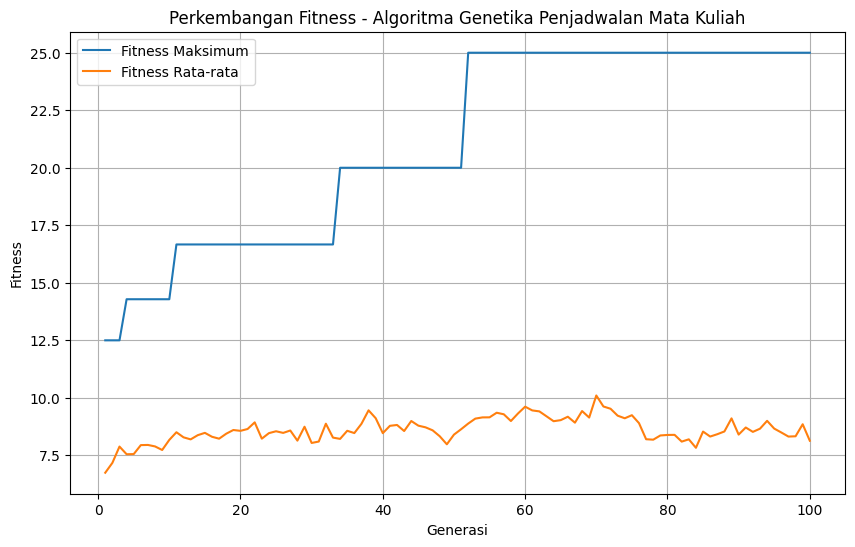

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, MAX_GEN + 1), history_max, label='Fitness Maksimum')
plt.plot(range(1, MAX_GEN + 1), history_avg, label='Fitness Rata-rata')
plt.title('Perkembangan Fitness - Algoritma Genetika Penjadwalan Mata Kuliah')
plt.xlabel('Generasi')
plt.ylabel('Fitness')
plt.legend()
plt.grid(True)
plt.savefig('grafik_evolusi_fitness.png', dpi=150, bbox_inches='tight')
plt.show()


## 11. Kesimpulan

_Algoritma genetika berhasil menurunkan konflik penjadwalan secara signifikan selama 100 generasi, dengan fitness maksimum menunjukkan pola tangga (staircase) akibat strategi elitism yang mempertahankan solusi terbaik di setiap generasi, sementara fitness rata-rata lebih fluktuatif karena pengaruh crossover dan mutasi yang menjaga keragaman populasi. Hasil akhir berupa fitness 25,00 dengan 3 konflik tersisa menunjukkan bahwa 100 generasi belum cukup untuk mencapai solusi optimal tanpa konflik, sehingga diperlukan perbaikan seperti memperbesar populasi atau jumlah generasi, menerapkan adaptive mutation rate, menggabungkan strategi local search/repair function, atau mencoba metode seleksi dan crossover alternatif untuk mempercepat konvergensi menuju solusi yang lebih optimal._
